<a href="https://colab.research.google.com/github/chandanar8126/zomato-eda-pluto-academy/blob/main/Zomato_EDA_PlutoAcademy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# connecting google drive so our file stays permanent
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Zomato Restaurant Data — Exploratory Data Analysis
### Pluto Academy AI & ML Internship | Project 01
**Name:** Chandana R

**Dataset:** Zomato
Restaurants Dataset (Kaggle)

**Objective:** Explore the dataset, find patterns, visualize key insights, and write 5 business recommendations based on the findings.

In [4]:
# importing all libraries needed for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# cleaner plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("all libraries loaded successfully")

all libraries loaded successfully


In [5]:
# loading the zomato dataset from google drive
# dataset source: https://www.kaggle.com/datasets/shrutimehta/zomato-restaurants-data

df = pd.read_csv('/content/drive/MyDrive/zomato.csv', encoding='latin-1')

# first look
print("Shape of dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

First 5 rows:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# checking data types of each column
print("Data Types:")
print(df.dtypes)

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object


In [7]:
#checking how many values are missing in each coloumn
missing = df.isnull( ).sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing % ' : missing_percent.round(2)
})

#only showing coloumns that actually have missing values
print("Columns with missing values:")
print(missing_df[missing_df['Missing Count']>0])

Columns with missing values:
          Missing Count  Missing % 
Cuisines              9        0.09


In [8]:
# checking for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## Data Summary — What This Dataset Contains

After loading and inspecting the dataset, here is what I found:

1. The dataset has 9551 rows and 21 columns covering restaurants from multiple countries worldwide.
2. Key columns include Restaurant Name, City, Cuisines, Average Cost for two, Aggregate Rating, and Votes.
3. The dataset is surprisingly clean — only 9 missing values found, all in the Cuisines column (0.09%).
4. Data types look correct — ratings are stored as decimals, costs and votes as integers.
5. There are zero duplicate rows, meaning every entry represents a unique restaurant.

## Step 2 — Cleaning the Data

Even though the dataset is mostly clean, I'll handle the missing values,
remove columns that won't help in analysis, and make sure everything
is in the right format before starting EDA.

In [9]:
# dropping columns that are not useful for analysis
# Restaurant ID - just an identifier, not analytical
# Address, Locality, Locality Verbose - too specific, City is enough
# Longitude, Latitude - we won't do map analysis
# Currency - most analysis will be within same currency groups
# Switch to order menu - almost all values are 'No', not useful

cols_to_drop = ['Restaurant ID', 'Address', 'Locality',
                'Locality Verbose', 'Longitude', 'Latitude',
                'Currency', 'Switch to order menu', 'Rating color']

df = df.drop(columns=cols_to_drop)

print("Columns after dropping irrelevant ones:")
print(df.columns.tolist())
print("\nNew shape:", df.shape)

Columns after dropping irrelevant ones:
['Restaurant Name', 'Country Code', 'City', 'Cuisines', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate rating', 'Rating text', 'Votes']

New shape: (9551, 12)


In [10]:
# dropping the 9 rows where Cuisines is missing
# only 0.09% of data - safe to drop, not worth guessing cuisine type

df = df.dropna(subset=['Cuisines'])

print("Rows after dropping missing Cuisines:", len(df))
print("Missing values remaining:", df.isnull().sum().sum())

Rows after dropping missing Cuisines: 9542
Missing values remaining: 0


In [11]:
# renaming columns to remove spaces - easier to work with
df.columns = ['restaurant_name', 'country_code', 'city', 'cuisines',
              'cost_for_two', 'table_booking', 'online_delivery',
              'delivering_now', 'price_range', 'rating',
              'rating_text', 'votes']

print("Renamed columns:")
print(df.columns.tolist())

Renamed columns:
['restaurant_name', 'country_code', 'city', 'cuisines', 'cost_for_two', 'table_booking', 'online_delivery', 'delivering_now', 'price_range', 'rating', 'rating_text', 'votes']


In [12]:
# final check after all cleaning steps
print("Final dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nSample data:")
df.head()

Final dataset shape: (9542, 12)

Data types:
restaurant_name     object
country_code         int64
city                object
cuisines            object
cost_for_two         int64
table_booking       object
online_delivery     object
delivering_now      object
price_range          int64
rating             float64
rating_text         object
votes                int64
dtype: object

Sample data:


,restaurant_name,country_code,city,cuisines,cost_for_two,table_booking,online_delivery,delivering_now,price_range,rating,rating_text,votes
0,Le Petit Souffle,162,Makati City,"French, Japanese, Desserts",1100,Yes,No,No,3,4.8,Excellent,314
1,Izakaya Kikufuji,162,Makati City,Japanese,1200,Yes,No,No,3,4.5,Excellent,591
2,Heat - Edsa Shangri-La,162,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,Yes,No,No,4,4.4,Very Good,270
3,Ooma,162,Mandaluyong City,"Japanese, Sushi",1500,No,No,No,4,4.9,Excellent,365
4,Sambo Kojin,162,Mandaluyong City,"Japanese, Korean",1500,Yes,No,No,4,4.8,Excellent,229


## Cleaning Decisions — Summary

Here is every cleaning step I performed and why:

| Decision | Reason |
|---|---|
| Dropped 9 irrelevant columns | Columns like Address, Locality, Longitude were not useful for pattern analysis |
| Dropped 9 rows with missing Cuisines | Only 0.09% of data — too few to impute, cuisine type is essential for analysis |
| Renamed all columns | Removed spaces from column names for easier coding |
| No missing values remain | Dataset is now 100% complete with 9542 rows and 12 columns |

The dataset is now clean, consistent, and ready for analysis.

## Step 3 — Exploratory Data Analysis

Now I'll answer 5 specific questions about the data using Pandas.
Each question has code, output, and a short observation.

### Question 1 — Which cities have the most restaurants in this dataset?
I want to find out which cities are most represented — this tells us
where Zomato is most active globally.

In [13]:
# finding top 10 cities by number of restaurants
top_cities = df['city'].value_counts().head(10)

print("Top 10 Cities by Number of Restaurants:")
print(top_cities)

Top 10 Cities by Number of Restaurants:
city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


**Observation:** New Delhi has by far the most restaurants (5473),
followed by Gurgaon (1118) and Noida (1080). This shows Zomato's
strongest presence is in the Delhi NCR region. Cities outside NCR
have significantly fewer listings.

### Question 2 — What is the distribution of ratings across all restaurants?
I want to understand how restaurants are generally rated — are most
restaurants well rated or poorly rated?

In [14]:
# checking distribution of ratings using rating_text column
rating_distribution = df['rating_text'].value_counts()

print("Rating Distribution:")
print(rating_distribution)

print("\nAverage rating across all restaurants:", round(df['rating'].mean(), 2))
print("Lowest rating:", df['rating'].min())
print("Highest rating:", df['rating'].max())

Rating Distribution:
rating_text
Average      3734
Not rated    2148
Good         2096
Very Good    1078
Excellent     300
Poor          186
Name: count, dtype: int64

Average rating across all restaurants: 2.67
Lowest rating: 0.0
Highest rating: 4.9


**Observation:**
Most restaurants fall in the "Average" category (3734),
followed by "Not rated" (2148) and "Good" (2096). Only 300 restaurants
are rated "Excellent". The overall average rating is 2.67 out of 5,
which is surprisingly low — this could be because many unrated
restaurants are pulling the average down.

### Question 3 — Which cuisines are most popular across all restaurants?
I want to find out what food types appear most frequently —
this tells us what cuisines dominate the platform.

In [15]:
# cuisines column has multiple cuisines per restaurant like "Indian, Chinese"
# need to split them and count each cuisine individually

all_cuisines = df['cuisines'].str.split(', ').explode()
top_cuisines = all_cuisines.value_counts().head(10)

print("Top 10 Most Popular Cuisines:")
print(top_cuisines)

Top 10 Most Popular Cuisines:
cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


**Observation:** North Indian cuisine is the most popular with 3960
restaurants, followed by Chinese (2735) and Fast Food (1986). This
makes sense given that most restaurants in this dataset are from
Delhi NCR. Italian and Continental cuisines also have a decent
presence showing international food options are available too.

### Question 4 — How many restaurants offer online delivery vs those that don't?
I want to understand how widely online delivery has been adopted
across restaurants on Zomato.

In [16]:
# checking online delivery adoption
delivery_counts = df['online_delivery'].value_counts()

print("Online Delivery Distribution:")
print(delivery_counts)

# percentage
delivery_percent = (delivery_counts / len(df) * 100).round(2)
print("\nPercentage:")
print(delivery_percent)

Online Delivery Distribution:
online_delivery
No     7091
Yes    2451
Name: count, dtype: int64

Percentage:
online_delivery
No     74.31
Yes    25.69
Name: count, dtype: float64


**Observation:** Only 25.69% of restaurants (2451) offer online delivery
while 74.31% (7091) do not. This is surprising given how popular food
delivery apps are today. This could mean that most restaurants in this
dataset are from an earlier time period when online delivery was not
as common, or that many smaller restaurants haven't adopted it yet.

### Question 5 — What is the relationship between cost and rating?
I want to check if more expensive restaurants tend to have
higher ratings — do you get what you pay for?

In [17]:
# grouping by price range and finding average rating and cost
price_vs_rating = df.groupby('price_range').agg(
    avg_rating = ('rating', 'mean'),
    avg_cost = ('cost_for_two', 'mean'),
    restaurant_count = ('restaurant_name', 'count')
).round(2)

print("Price Range vs Average Rating:")
print(price_vs_rating)

Price Range vs Average Rating:
             avg_rating  avg_cost  restaurant_count
price_range                                        
1                  2.00    275.55              4438
2                  2.94    596.83              3113
3                  3.68   5188.24              1405
4                  3.82   1848.52               586


**Observation:** There is a clear positive relationship between price
range and rating. Price range 1 (cheapest) has an average rating of
2.00 while price range 4 (most expensive) has an average rating of
3.82. This suggests that more expensive restaurants tend to offer
better quality and service. However price range 1 has the most
restaurants (4438) meaning most restaurants on Zomato are budget
friendly options.

## Step 4 — Visualizations

I will now create 6 different chart types to visually represent
the key findings from the EDA. Each chart has a title, axis labels,
and a short observation below it.

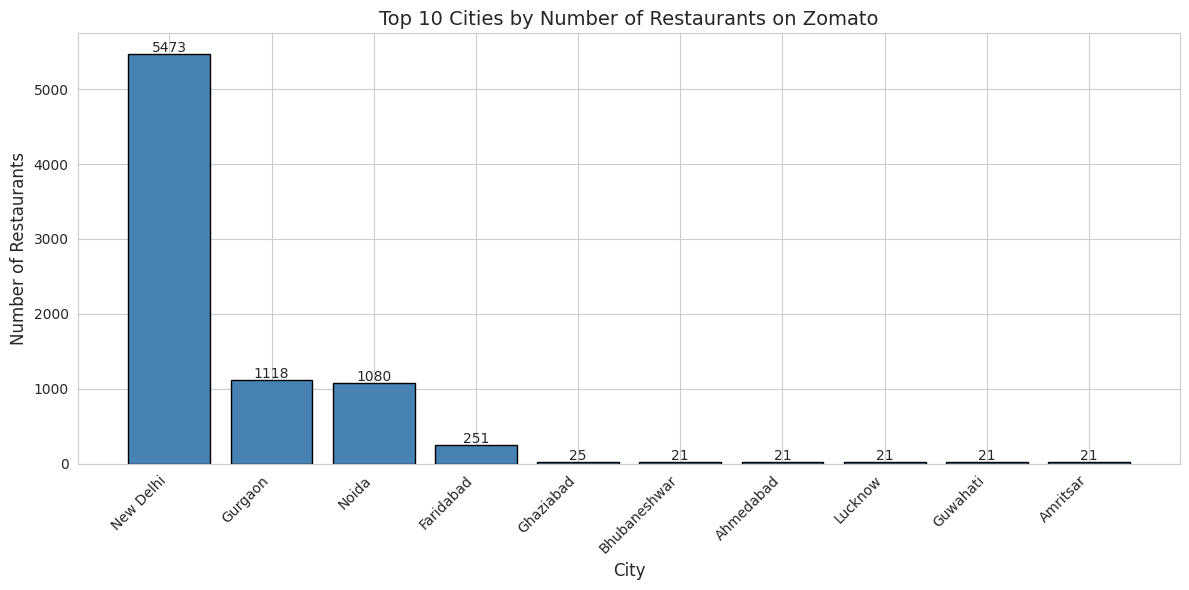

In [18]:
# Chart 1 - Bar Chart
# Top 10 cities by number of restaurants

top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_cities.index, top_cities.values, color='steelblue', edgecolor='black')

# adding value labels on top of each bar
for bar, value in zip(bars, top_cities.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             str(value),
             ha='center', fontsize=10)

plt.title('Top 10 Cities by Number of Restaurants on Zomato', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Chart 1 Observation:** New Delhi has an overwhelming number of
restaurants (5473) compared to all other cities. Gurgaon and Noida
follow but with significantly fewer listings. This confirms Zomato's
strongest market is Delhi NCR.

In [ ]:
 ly g

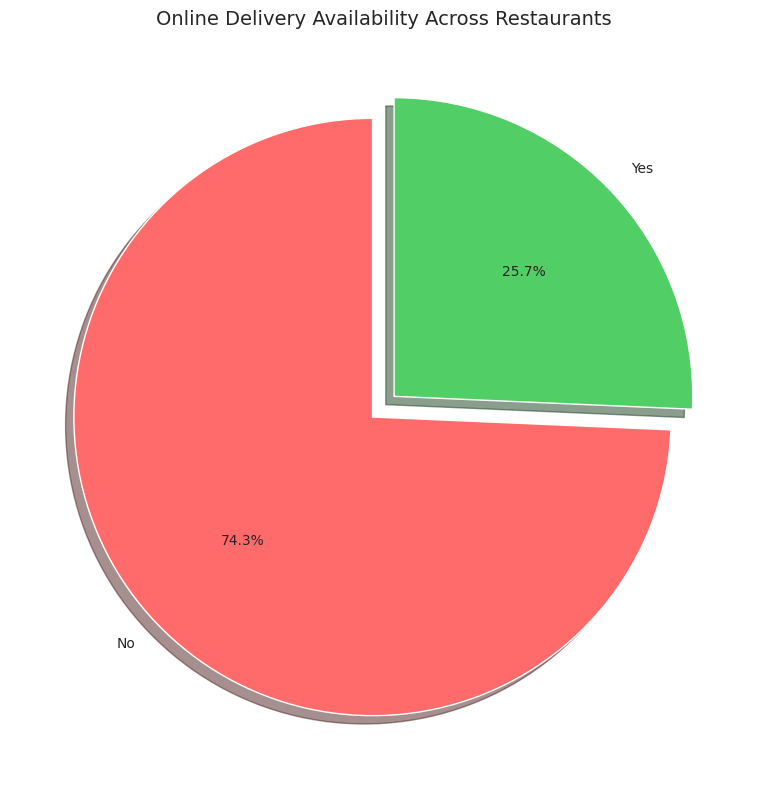

In [19]:
# Chart 2 - Pie Chart
# Online delivery distribution

delivery_counts = df['online_delivery'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(delivery_counts.values,
        labels=delivery_counts.index,
        autopct='%1.1f%%',
        colors=['#ff6b6b', '#51cf66'],
        startangle=90,
        explode=(0.05, 0.05),
        shadow=True)

plt.title('Online Delivery Availability Across Restaurants', fontsize=14)
plt.tight_layout()
plt.show()

**Chart 2 Observation:** A large majority of restaurants (74.3%) do
not offer online delivery. Only 25.7% have online delivery enabled.
This shows there is still a huge opportunity for Zomato to onboard
more restaurants onto their delivery platform.

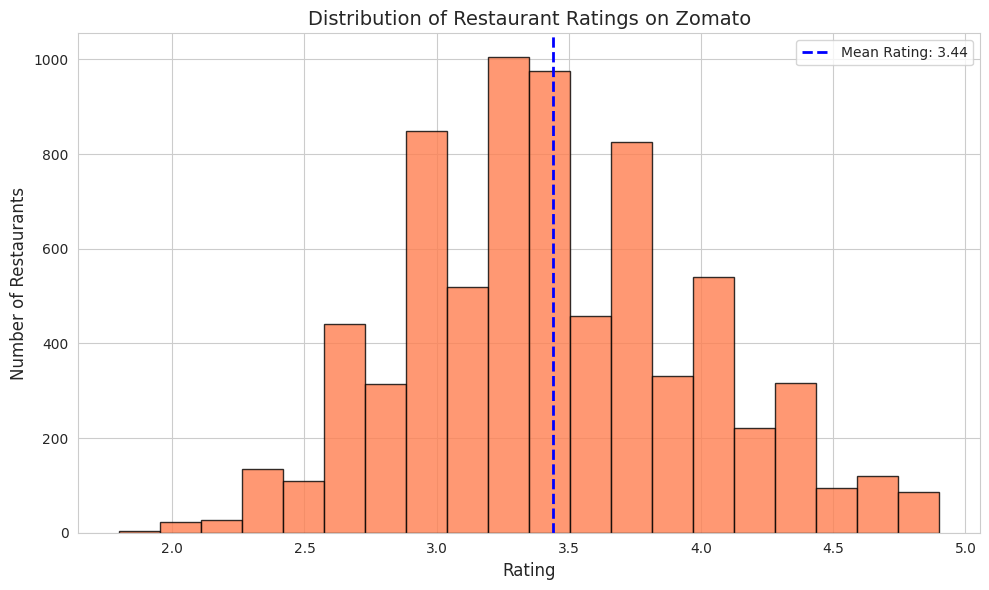

In [20]:
# Chart 3 - Histogram
# Distribution of restaurant ratings

# filtering out unrated restaurants for cleaner visualization
rated_df = df[df['rating'] > 0]

plt.figure(figsize=(10, 6))
plt.hist(rated_df['rating'], bins=20, color='coral',
         edgecolor='black', alpha=0.8)

plt.title('Distribution of Restaurant Ratings on Zomato', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.axvline(rated_df['rating'].mean(), color='blue',
            linestyle='dashed', linewidth=2,
            label=f"Mean Rating: {rated_df['rating'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

**Chart 3 Observation:** The rating distribution is slightly left skewed
meaning most rated restaurants cluster between 3.0 and 4.0. The mean
rating is around 3.5 for restaurants that have actually been rated.
Very few restaurants have extremely low or extremely high ratings
which is typical for large food platforms.